In [20]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import tensorflow as tf

from tensorflow.keras.utils import to_categorical

from tensorflow.keras.applications import MobileNetV2

from tensorflow.keras.layers import (
    Dense,
    GlobalAveragePooling2D,
    Dropout
)

from tensorflow.keras.models import Model

from tensorflow.keras.optimizers import Adam


In [21]:
X = []
Y = []

img_size = 224

# Kaggle training dataset path
base_path = "/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Training"

classes = {
    'no_tumor': 0,
    'pituitary_tumor': 1,
    'glioma_tumor': 2,
    'meningioma_tumor': 3
}
for cls, label in classes.items():
    path = os.path.join(base_path, cls)

    for filename in os.listdir(path):

        img_path = os.path.join(path, filename)

        # Read image
        img = cv2.imread(img_path)

        # Skip corrupted images
        if img is None:
            continue

        # Resize image
        img = cv2.resize(img, (img_size, img_size))

        # Convert BGR to RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Normalize image
        img = img.astype('float32') / 255.0

        # Store image and label
        X.append(img)
        Y.append(label)

# Convert into numpy arrays
X = np.array(X)
Y = np.array(Y)

print("X shape :", X.shape)
print("Y shape :", Y.shape)



X shape : (2870, 224, 224, 3)
Y shape : (2870,)


In [22]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

ONE HOT ENCODING

In [23]:
Y_train = to_categorical(Y_train, num_classes=4)

Y_test = to_categorical(Y_test, num_classes=4)


In [24]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

In [25]:
for layer in base_model.layers:
    layer.trainable = False

#Freezing Pretrained Layers


In [26]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dropout(0.5)(x)

predictions = Dense(4, activation='softmax')(x)

#Custom Classifier

In [27]:
#Final Model
model = Model(
    inputs=base_model.input,
    outputs=predictions
)


In [28]:
#Compile Model
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [29]:
#Model Summary
model.summary()

#Training
history = model.fit(
    X_train,
    Y_train,
    validation_data=(X_test, Y_test),
    epochs=100,
    batch_size=32
)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 22s 199ms/step - accuracy: 0.2501 - loss: 1.8619 - val_accuracy: 0.4199 - val_loss: 1.2433
Epoch 2/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.3425 - loss: 1.5575 - val_accuracy: 0.5679 - val_loss: 1.0601
Epoch 3/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.4303 - loss: 1.3344 - val_accuracy: 0.6446 - val_loss: 0.9304
Epoch 4/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.4973 - loss: 1.1860 - val_accuracy: 0.6899 - val_loss: 0.8357
Epoch 5/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.5381 - loss: 1.0855 - val_accuracy: 0.7387 - val_loss: 0.7620
Epoch 6/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.5713 - loss: 1.0036 - val_accuracy: 0.7561 - val_loss: 0.7083
Epoch 7/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.6303 - loss: 0.9095 - val_accuracy: 0.7666 - val_loss: 0.6637
Epoch 8/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.6354 - loss: 0.8715 - val_accuracy: 

In [30]:
#Model Evaluation

loss, accuracy = model.evaluate(X_test, Y_test)

print("Test Loss :", loss)

print("Test Accuracy :", accuracy)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9056 - loss: 0.2945
Test Loss : 0.3178781270980835
Test Accuracy : 0.8867595791816711


In [31]:
#Predictions
predictions = model.predict(X_test)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = np.argmax(Y_test, axis=1)


18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 264ms/step


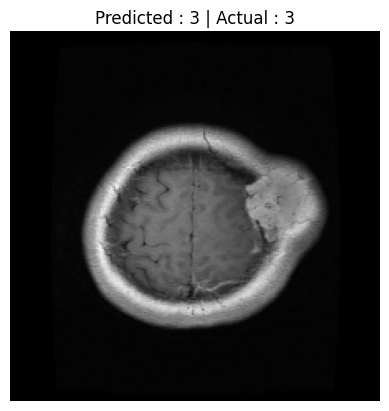

In [32]:
#Display
index = 0

plt.imshow(X_test[index])

plt.title(
    f"Predicted : {predicted_classes[index]} | Actual : {true_classes[index]}"
)

plt.axis("off")

plt.show()

In [33]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Convert one-hot encoded labels back to integers
y_true = np.argmax(Y_test, axis=1)

# Predicted class labels
y_pred = np.argmax(predictions, axis=1)


# ACCURACY

accuracy = accuracy_score(y_true, y_pred)

print("Accuracy :", accuracy)



# F1 SCORE


f1 = f1_score(y_true, y_pred, average='weighted')

print("F1 Score :", f1)



# CONFUSION MATRIX


cm = confusion_matrix(y_true, y_pred)

print("\nConfusion Matrix:\n")

print(cm)



# SENSITIVITY AND SPECIFICITY


num_classes = 4

sensitivity_list = []
specificity_list = []

for i in range(num_classes):

    TP = cm[i, i]

    FN = np.sum(cm[i, :]) - TP

    FP = np.sum(cm[:, i]) - TP

    TN = np.sum(cm) - (TP + FP + FN)

    sensitivity = TP / (TP + FN)

    specificity = TN / (TN + FP)

    sensitivity_list.append(sensitivity)

    specificity_list.append(specificity)

    print(f"\nClass {i}")

    print("Sensitivity :", sensitivity)

    print("Specificity :", specificity)



# AVERAGE METRICS


print("\nAverage Sensitivity :", np.mean(sensitivity_list))

print("Average Specificity :", np.mean(specificity_list))



# FULL CLASSIFICATION REPORT


print("\nClassification Report:\n")

print(classification_report(y_true, y_pred))

Accuracy : 0.8867595818815331
F1 Score : 0.8872985814363162

Confusion Matrix:

[[ 69   2   1   7]
 [  0 162   1   3]
 [  0   0 137  28]
 [  2   6  15 141]]

Class 0
Sensitivity : 0.8734177215189873
Specificity : 0.9959595959595959

Class 1
Sensitivity : 0.9759036144578314
Specificity : 0.9803921568627451

Class 2
Sensitivity : 0.8303030303030303
Specificity : 0.9584352078239609

Class 3
Sensitivity : 0.8597560975609756
Specificity : 0.9073170731707317

Average Sensitivity : 0.8848451159602061
Average Specificity : 0.9605260084542584

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.87      0.92        79
           1       0.95      0.98      0.96       166
           2       0.89      0.83      0.86       165
           3       0.79      0.86      0.82       164

    accuracy                           0.89       574
   macro avg       0.90      0.88      0.89       574
weighted avg       0.89      0.89      0.89       574

